In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv("SampleSuperstore.csv")

# Preview data
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08-11-2017,11-11-2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08-11-2017,11-11-2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12-06-2017,16-06-2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11-10-2016,18-10-2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11-10-2016,18-10-2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [4]:
df.drop_duplicates(inplace=True)

In [6]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

In [8]:
import numpy as np

df['Quantity'] = np.random.randint(1, 10, size=len(df))

In [9]:
df['Profit'] = df['Sales'] * np.random.uniform(0.05, 0.3, size=len(df))

In [10]:
import numpy as np

# Fix column names
df.columns = df.columns.str.strip()

# Add Quantity if missing
if 'Quantity' not in df.columns:
    df['Quantity'] = np.random.randint(1, 10, size=len(df))

# Add Profit if missing
if 'Profit' not in df.columns:
    df['Profit'] = df['Sales'] * np.random.uniform(0.05, 0.3, size=len(df))

In [11]:
df['Quantity'].head()
df['Profit'].head()

0     65.338510
1    101.240456
2      2.042826
3    136.795345
4      4.873215
Name: Profit, dtype: float64

In [12]:
df['Sales'] = pd.to_numeric(df['Sales'])
df['Quantity'] = pd.to_numeric(df['Quantity'])
df['Profit'] = pd.to_numeric(df['Profit'])

In [13]:
df['Postal Code'] = df['Postal Code'].astype(str)

In [14]:
df.to_csv("final_sales_data.csv", index=False)

In [15]:
total_sales = df['Sales'].sum()
print("Total Sales:", total_sales)

Total Sales: 2261536.7827


In [16]:
total_orders = df['Order ID'].nunique()
print("Total Orders:", total_orders)

Total Orders: 4922


In [17]:
total_quantity = df['Quantity'].sum()
print("Total Quantity:", total_quantity)

Total Quantity: 49487


In [18]:
avg_order_value = total_sales / total_orders
print("Avg Order Value:", avg_order_value)

Avg Order Value: 459.4751691791954


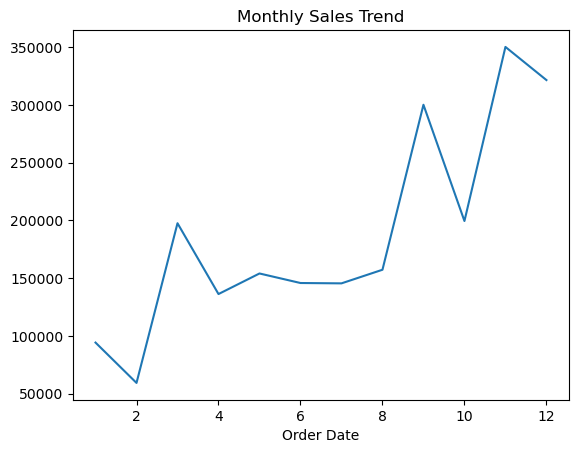

In [19]:
import matplotlib.pyplot as plt

df.groupby(df['Order Date'].dt.month)['Sales'].sum().plot(kind='line')
plt.title("Monthly Sales Trend")
plt.show()

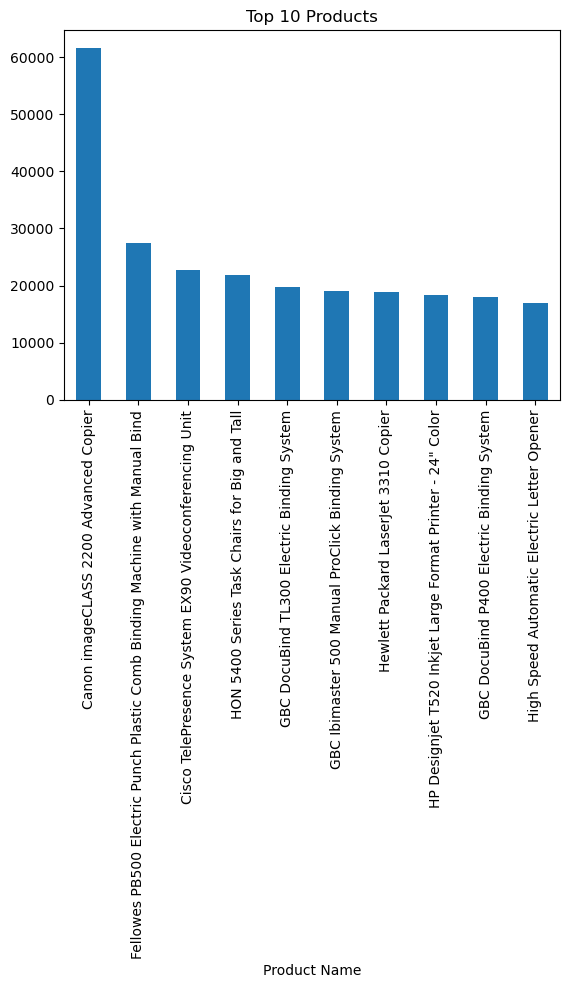

In [20]:
df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Products")
plt.show()

In [22]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed', dayfirst=True, errors='coerce')

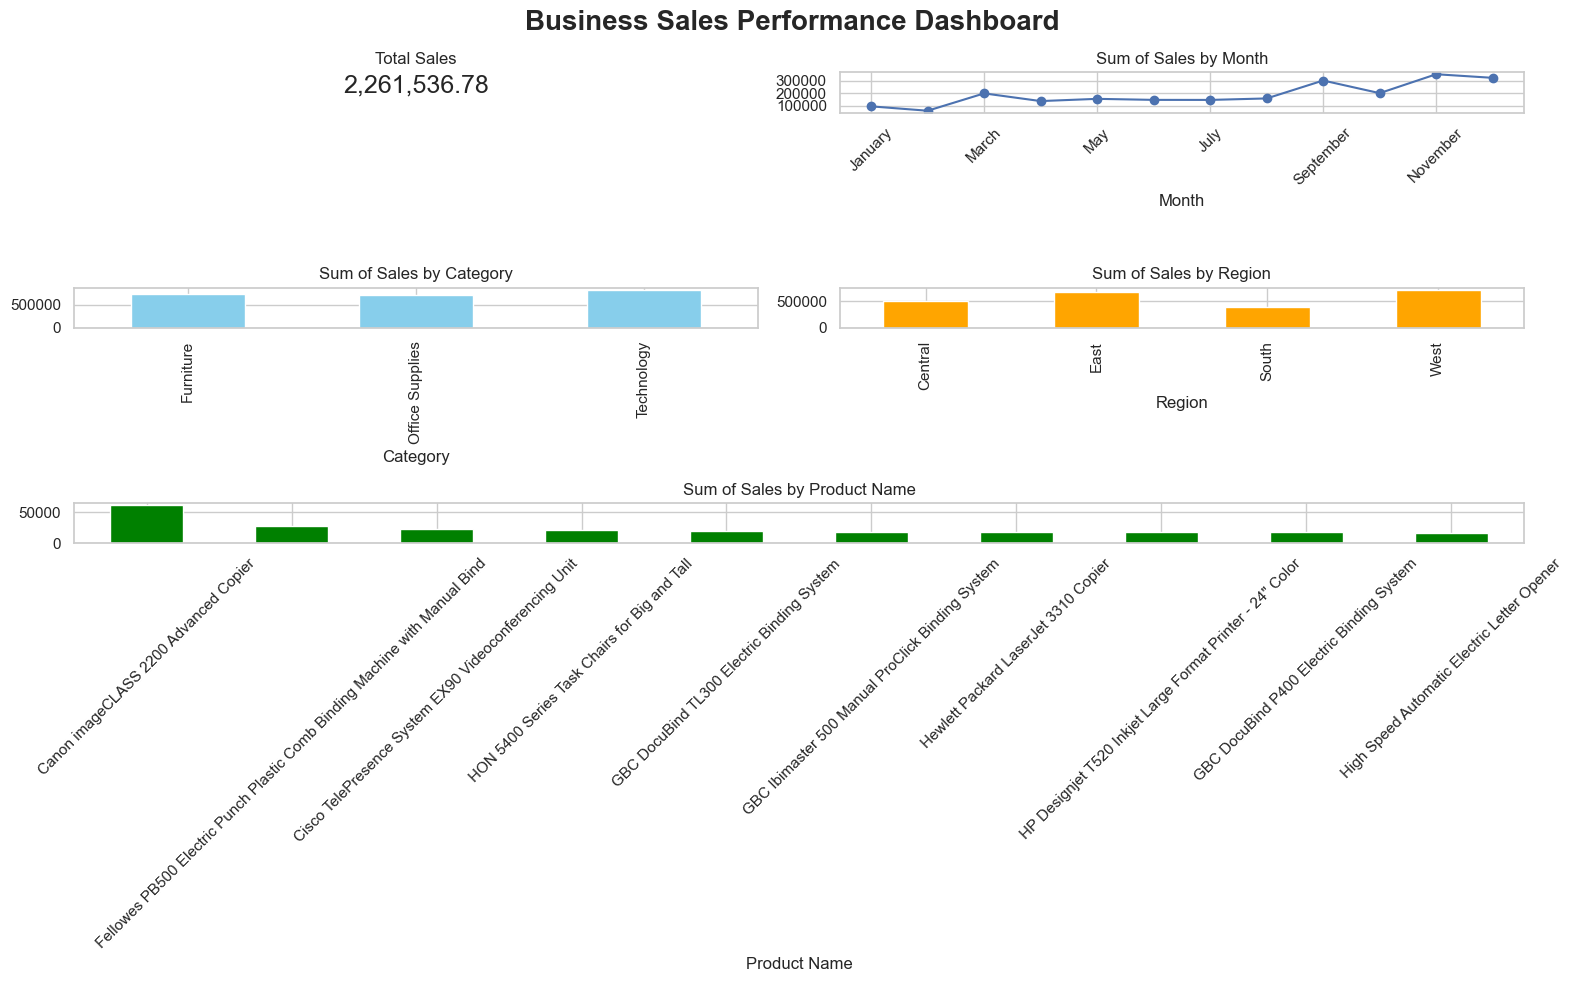

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Style
sns.set(style="whitegrid")

# Load data
df = pd.read_csv("final_sales_data.csv")

# Convert date
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed', dayfirst=True, errors='coerce')

# Extract Month
df['Month'] = df['Order Date'].dt.month_name()

# KPIs
total_sales = df['Sales'].sum()

# Grouped data
monthly_sales = df.groupby('Month')['Sales'].sum()
category_sales = df.groupby('Category')['Sales'].sum()
region_sales = df.groupby('Region')['Sales'].sum()
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

# Sort months properly
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
monthly_sales = monthly_sales.reindex(month_order)

# Create figure
fig = plt.figure(figsize=(16,10))
fig.suptitle("Business Sales Performance Dashboard", fontsize=20, fontweight='bold')

# KPI CARD
plt.subplot(3,2,1)
plt.text(0.5, 0.5, f"{total_sales:,.2f}", fontsize=18, ha='center')
plt.title("Total Sales")
plt.axis('off')

# Monthly Sales
plt.subplot(3,2,2)
monthly_sales.plot(kind='line', marker='o')
plt.title("Sum of Sales by Month")
plt.xticks(rotation=45)

# Category
plt.subplot(3,2,3)
category_sales.plot(kind='bar', color='skyblue')
plt.title("Sum of Sales by Category")

# Region
plt.subplot(3,2,4)
region_sales.plot(kind='bar', color='orange')
plt.title("Sum of Sales by Region")

# Top Products (full width)
plt.subplot(3,1,3)
top_products.plot(kind='bar', color='green')
plt.title("Sum of Sales by Product Name")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [24]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed', dayfirst=True, errors='coerce')